# 01 — Exploratory analysis: commodities vs macro

**Phase 2.** Descriptive research on the commodities track. The goal is to find
structure — which commodities move with which macro factors, and whether those
relationships are stable or regime-dependent — *not* to predict prices yet.

**Discipline:** all analysis here is restricted to the EXPLORE window
(`<= EXPLORE_END`). The holdout is never touched in this notebook. When a
finding looks real, it graduates to a holdout check in a later notebook.

In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
import config

pd.set_option("display.width", 120)
plt.rcParams["figure.figsize"] = (11, 5)

## Load — and immediately cut to the explore window

In [3]:
daily = pd.read_parquet(config.DATA / "commodities_daily.parquet")
monthly = pd.read_parquet(config.DATA / "commodities_monthly.parquet")

# HARD boundary: explore only. Holdout is not loaded into any analysis object.
daily_ex = daily.loc[:config.EXPLORE_END].copy()
monthly_ex = monthly.loc[:config.EXPLORE_END].copy()

print("explore ends:", config.EXPLORE_END)
print("daily explore:", daily_ex.shape, daily_ex.index.min().date(), "->", daily_ex.index.max().date())
print("monthly explore:", monthly_ex.shape)
daily_ex.columns.tolist()

explore ends: 2021-12-31
daily explore: (13514, 22) 1985-01-01 -> 2021-12-31
monthly explore: (444, 22)


['wti_usd',
 'brent_usd',
 'natgas_usd',
 'copper_usd',
 'gold',
 'silver',
 'wti',
 'brent',
 'natgas',
 'copper',
 'palladium',
 'platinum',
 'usd_broad',
 'ust10y_nominal',
 'ust10y_real',
 'vix',
 'fed_funds',
 'cpi_ff',
 'pce_ff',
 'm2_ff',
 'industrial_production_ff',
 'unemployment_ff']

## Returns, not levels

Price *levels* are non-stationary and their correlations are mostly spurious
(both trending). Work in returns for anything correlational. Keep levels only
for plotting.

In [4]:
price_cols = ["gold", "silver", "wti", "brent", "natgas", "copper", "palladium", "platinum"]
macro_cols = ["usd_broad", "ust10y_nominal", "ust10y_real", "vix", "fed_funds"]

# monthly log returns for the price series; monthly diffs for macro (yields/vix
# are already in rate/level space, so first-difference rather than log-return)
rets = np.log(monthly_ex[price_cols]).diff()
macro_chg = monthly_ex[macro_cols].diff()
panel = pd.concat([rets, macro_chg], axis=1).dropna(how="all")
panel.describe().round(3).T[["mean", "std", "min", "max"]]

,mean,std,min,max
gold,0.007,0.048,-0.199,0.130
silver,0.006,0.089,-0.328,0.266
wti,0.003,0.113,-0.782,0.633
brent,0.000,0.113,-0.798,0.335
natgas,-0.001,0.151,-0.548,0.486
copper,0.006,0.076,-0.449,0.293
palladium,0.004,0.100,-0.302,0.385
platinum,0.003,0.062,-0.224,0.216
usd_broad,0.083,1.772,-4.836,7.389
ust10y_nominal,-0.022,0.281,-1.130,0.950


## Correlation structure — commodities among themselves

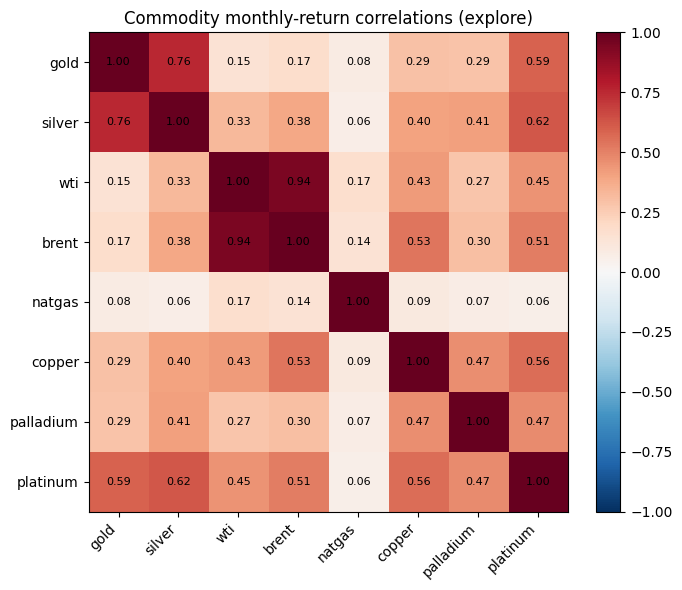

In [5]:
corr = rets.corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(price_cols))); ax.set_xticklabels(price_cols, rotation=45, ha="right")
ax.set_yticks(range(len(price_cols))); ax.set_yticklabels(price_cols)
for i in range(len(price_cols)):
    for j in range(len(price_cols)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, fraction=0.046); plt.title("Commodity monthly-return correlations (explore)")
plt.tight_layout(); plt.show()

**Read this for:** the precious-metals block (gold/silver/platinum/palladium
should cluster), the energy block (wti/brent near-collinear — expected), and
whether copper sides with metals or energy (it's often a growth proxy, so it
may not sit cleanly in either).

## Commodities vs macro — the actual question

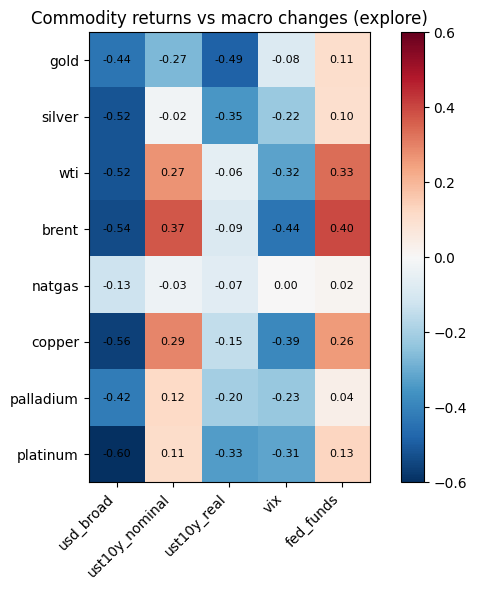

,usd_broad,ust10y_nominal,ust10y_real,vix,fed_funds
gold,-0.44,-0.27,-0.49,-0.08,0.11
silver,-0.52,-0.02,-0.35,-0.22,0.10
wti,-0.52,0.27,-0.06,-0.32,0.33
brent,-0.54,0.37,-0.09,-0.44,0.40
natgas,-0.13,-0.03,-0.07,0.00,0.02
copper,-0.56,0.29,-0.15,-0.39,0.26
palladium,-0.42,0.12,-0.20,-0.23,0.04
platinum,-0.60,0.11,-0.33,-0.31,0.13


In [6]:
cross = pd.DataFrame(index=price_cols, columns=macro_cols, dtype=float)
for p in price_cols:
    for m in macro_cols:
        cross.loc[p, m] = panel[p].corr(panel[m])
cross = cross.astype(float)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cross, cmap="RdBu_r", vmin=-0.6, vmax=0.6)
ax.set_xticks(range(len(macro_cols))); ax.set_xticklabels(macro_cols, rotation=45, ha="right")
ax.set_yticks(range(len(price_cols))); ax.set_yticklabels(price_cols)
for i in range(len(price_cols)):
    for j in range(len(macro_cols)):
        ax.text(j, i, f"{cross.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, fraction=0.046); plt.title("Commodity returns vs macro changes (explore)")
plt.tight_layout(); plt.show()
cross.round(2)

**Hypotheses to check against this:**
- gold vs `ust10y_real` — the textbook negative link (real yields = opportunity
  cost of holding non-yielding gold). If it's weak here, that's itself interesting.
- energy vs `usd_broad` — commodities are USD-priced, so a stronger dollar
  usually pushes prices down (expect negative).
- gold/metals vs `vix` — the safe-haven story; expect mild positive.

Note whether any sign *disagrees* with the textbook. That's where the research
lives — and echoes the stock/bond finding that a relationship's sign can flip
depending on how you operationalize the macro variable.

## Rolling correlation — is the relationship stable?

A single full-sample number hides regime changes. The gold–real-yield link, in
particular, is widely believed to have weakened/shifted. Roll it.

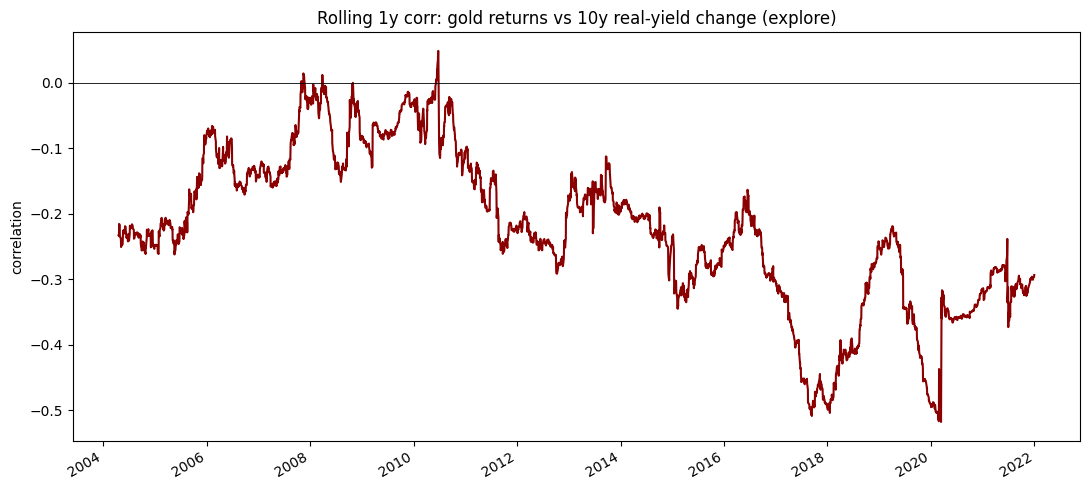

valid rolling points: 3445 | span: 2004-04-20 -> 2021-12-31


In [8]:
# align to the overlapping non-NaN window BEFORE rolling, else the sparse
# early history (yfinance gold history + pre-2003 TIPS gap) blanks the plot
d = daily_ex.copy()
pair = pd.concat([np.log(d["gold"]).diff(), d["ust10y_real"].diff()], axis=1).dropna()
pair.columns = ["gold_ret", "real_chg"]
roll = pair["gold_ret"].rolling(252).corr(pair["real_chg"])

fig, ax = plt.subplots()
roll.plot(ax=ax, color="darkred")
ax.axhline(0, color="k", lw=0.6)
ax.set_title("Rolling 1y corr: gold returns vs 10y real-yield change (explore)")
ax.set_ylabel("correlation"); plt.tight_layout(); plt.show()

print("valid rolling points:", int(roll.notna().sum()), "| span:", roll.dropna().index.min().date(), "->", roll.dropna().index.max().date())

**If this line wanders across zero,** a static model is mis-specified and the
honest framing is regime-dependent — which points the prediction phase toward
regime/correlation-shift targets rather than next-day price direction.

## Next
- Add World Bank Pink Sheet minerals (`fetch_slow.py`) if metals structure looks
  worth expanding.
- Regime detection (volatility states / changepoints) on the series that show
  the most unstable macro links.
- Only what survives here graduates to a holdout check.